# Survey Analysis (Merged.csv)

This notebook provides a full analysis of the merged survey dataset, including:
- Data cleaning and consent filtering
- Demographics and respondent profile
- AI usage and citation integrity behaviors
- BibTeX consistency check (conflict rule)
- Key findings and a Markdown report


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('figs', exist_ok=True)

# Match the line chart style provided
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.facecolor': '#FFFFFF',
    'figure.facecolor': 'white',
    'mathtext.fontset': 'stixsans',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
})

sns.set_theme(style='whitegrid', context='paper')

# Pastel RGB primaries
PALETTE = ['#5A5ADD', '#FF6060', '#5CCB6A']

DATA_PATH = './statistics.csv'
print('Ready:', DATA_PATH)

Ready: ./statistics.csv


In [2]:
df_raw = pd.read_csv(DATA_PATH)
print('Rows:', len(df_raw))
print('Columns:', len(df_raw.columns))


def find_column(df, keyword):
    matches = [c for c in df.columns if keyword.lower() in str(c).lower()]
    if len(matches) == 0:
        raise ValueError(f'Column not found for keyword: {keyword}')
    if len(matches) > 1:
        print('Multiple matches for', keyword, '->', matches)
    return matches[0]


def find_column_any(df, keywords):
    for c in df.columns:
        c_lower = str(c).lower()
        if any(k.lower() in c_lower for k in keywords):
            return c
    return None

print('Loaded columns sample:', list(df_raw.columns)[:5])

Rows: 103
Columns: 43
Loaded columns sample: ['Index', 'By clicking "Yes" below, you confirm that:\n1.You understand that your participation is voluntary.\n2.You understand that you may stop the survey and quit at any time without giving a reason.\n3.You consent to the anonymous use of your responses for research purposes.', 'What is your current academic position?', 'Which research area best describes your work?', 'How many peer-reviewed papers have you published in your career?']


In [3]:
# Basic cleanup: drop fully empty rows
_df = df_raw.replace('', np.nan).dropna(how='all').copy()

# Consent filtering (keep only explicit consent if column exists)
consent_col = find_column_any(_df, ['consent', '参与'])
if consent_col:
    def is_consent_yes(value):
        if pd.isna(value):
            return False
        text = str(value).strip()
        text_lower = text.lower()
        return ('consent' in text_lower and 'yes' in text_lower) or ('同意参与' in text)

    before = len(_df)
    _df = _df[_df[consent_col].apply(is_consent_yes)].copy()
    print('Consent column:', consent_col)
    print('Rows after consent filter:', len(_df), f'(dropped {before - len(_df)})')
else:
    print('No consent column found; keeping all rows')

# Final cleaned dataset
_df.reset_index(drop=True, inplace=True)
df = _df
print('Cleaned rows:', len(df))

# Columns used later
verify_col = find_column(df, 'I meticulously verify every single field')
copy_col = find_column(df, 'copy-pasted a BibTeX entry')

print('Verify column:', verify_col)
print('Copy-paste column:', copy_col)

Consent column: By clicking "Yes" below, you confirm that:
1.You understand that your participation is voluntary.
2.You understand that you may stop the survey and quit at any time without giving a reason.
3.You consent to the anonymous use of your responses for research purposes.
Rows after consent filter: 97 (dropped 6)
Cleaned rows: 97
Verify column: To what extent do you agree: "I meticulously verify every single field (volume, issue, page numbers) of every BibTeX entry I import, ensuring 100% accuracy before submission."
Copy-paste column: Have you ever copy-pasted a BibTeX entry from the internet without checking its content?


## 2. Helper Functions

In [4]:
import re
import pandas as pd

def split_multi(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    # Avoid splitting on commas because many options contain commas inside parentheses.
    parts = re.split(r'\s*&\s*|;|；|\r?\n|\s*\|\s*|、', text)
    return [p.strip() for p in parts if p.strip()]

def count_values(series, multi=False):
    counts = {}
    for val in series.dropna():
        if multi:
            items = split_multi(val)
        else:
            items = [str(val).strip()]
        for item in items:
            if item:
                counts[item] = counts.get(item, 0) + 1
    return pd.Series(counts).sort_values(ascending=False)

def get_col(keyword):
    try:
        return find_column(df, keyword)
    except Exception:
        return None

def plot_bar(series, title, filename, xlabel='Count'):
    if series is None or series.empty:
        print('Skip plot (empty):', title)
        return
    fig, ax = plt.subplots(figsize=(3.5, 2))
    series[::-1].plot(kind='barh', ax=ax, color=PALETTE[0])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis='x', alpha=0.3)
    for i, val in enumerate(series[::-1].values):
        ax.text(val, i, f'{int(val)}', va='center', ha='left', fontsize=10.5)
    plt.tight_layout(pad=0.36)
    plt.savefig(filename, dpi=300)
    plt.show()

def plot_barh(series, title, filename, xlabel='Count'):
    if series is None or series.empty:
        print('Skip plot (empty):', title)
        return
    fig, ax = plt.subplots(figsize=(3.5, 2))
    series[::-1].plot(kind='barh', ax=ax, color=PALETTE[0])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis='x', alpha=0.3)
    for i, val in enumerate(series[::-1].values):
        ax.text(val, i, f'{int(val)}', va='center', ha='left', fontsize=10.5)
    plt.tight_layout(pad=0.36)
    plt.savefig(filename, dpi=300)
    plt.show()

def triad_gradient(n):
    if n <= 0:
        return []
    anchors = [  (0.35, 0.35, 0.87),(0.36, 0.78, 0.46), (0.98, 0.45, 0.45)]
    colors = []
    for i in range(n):
        t = i / max(n - 1, 1)
        if t <= 0.5:
            a, b = anchors[0], anchors[1]
            u = t / 0.5
        else:
            a, b = anchors[1], anchors[2]
            u = (t - 0.5) / 0.5
        colors.append((a[0] + (b[0] - a[0]) * u, a[1] + (b[1] - a[1]) * u, a[2] + (b[2] - a[2]) * u))
    return colors

def setup_usenix_style():
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
        'font.size': 8,
        'font.weight': 'normal',
        'axes.titlesize': 9,
        'axes.titleweight': 'bold',
        'axes.labelsize': 8,
        'legend.fontsize': 7,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'axes.linewidth': 0.5,
    })

def plot_pie(
    series,
    title,
    filename,
    top_n=8,
    max_label_len=26,
    legend_cols=1,
    figsize=(2.4, 2.4),
    legend_fontsize=9,
    text_fontsize=9.5,
    legend_right=True,
    title_on=False,
    legend_anchor=(1.02, 0.5),
    tight_pad=0.36,
    legend_text=False,
    ):
    if series is None or series.empty:
        print('Skip plot (empty):', title)
        return
    data = series.copy()
    if top_n and len(data) > top_n:
        top = data.head(top_n)
        other = data.iloc[top_n:].sum()
        data = top.copy()
        if other > 0:
            data.loc['Other'] = other
    filtered = {k: v for k, v in data.items() if v > 0}
    if not filtered:
        print('Skip plot (empty):', title)
        return
    setup_usenix_style()
    fig, ax = plt.subplots(figsize=figsize)
    colors = triad_gradient(len(filtered))
    radius = 1.3
    wedges, _ = ax.pie(
        list(filtered.values()),
        colors=colors,
        startangle=90,
        radius=radius,
        wedgeprops={'linewidth': 1.5, 'edgecolor': 'white', 'width': 0.5},
    )
    def short_label(label):
        label = str(label)
        return label if len(label) <= max_label_len else label[:max_label_len - 1] + '…'
    limit = 3.6
    ax.set_xlim(-limit, limit)
    for wedge, (label, count) in zip(wedges, filtered.items()):
        ang = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
        if label == 'Software Eng.':
            ang += 1
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))
        x_text = 1.5 if x >= 0 else -1.5
        ha = 'left' if x >= 0 else 'right'
        if label in ('Soft. Eng.', 'Software Engineering'):
            x_text = -1.5
            ha = 'right'
        if label == 'Other':
            x_text = -1.5
            ha = 'right'
        y_ann = 1.4 * y
        ax.annotate(
            f'{short_label(label)}: {int(count)}',
            xy=(x, y),
            xytext=(x_text, y_ann),
            fontsize=text_fontsize,
            ha=ha,
            va='center',
            arrowprops=dict(
                arrowstyle='-',
                color='#222222',
                lw=0.6,
                connectionstyle='angle,angleA=0,angleB=90,rad=0',
            ),
        )
    if title == 'Research\nArea':
        ax.text(
            0,
            -0.05,
            f'{title}',
            ha='center',
            va='center',
            fontsize=8.5,
            linespacing=1.3,
            fontweight='bold',
        )
    else:
        ax.text(
            0,
            0,
            f'{title}',
            ha='center',
            va='center',
            fontsize=8.5,
            linespacing=1.3,
            fontweight='bold',
        )
    ax.axis('equal')
    plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()

print('Helpers ready')

Helpers ready


## 3. Demographics and Profile

Position counts:
 PhD Student                     33
Master's Student                19
Faculty (Professor/Lecturer)    17
Undergraduate student           15
Postdoc                          6
Researcher                       5
Other                            2
dtype: int64
Area counts:
 Other                    25
AI & Machine Learning    20
Network Security         19
AI Security              13
System Security          10
Cryptography              6
Software Engineering      4
dtype: int64


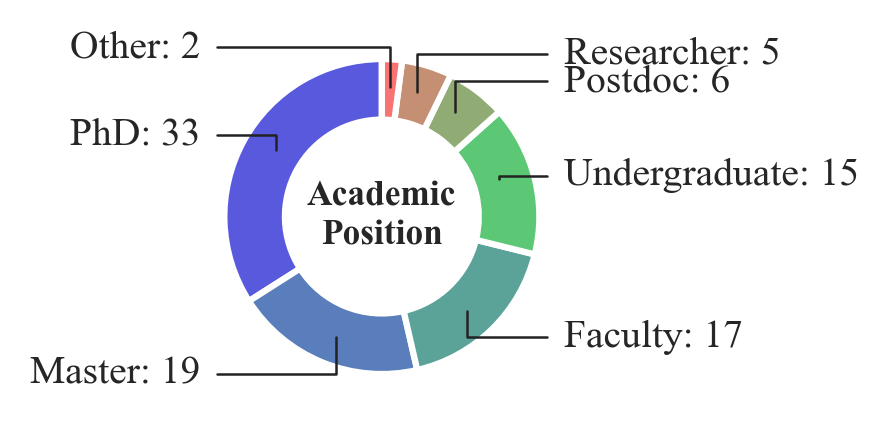

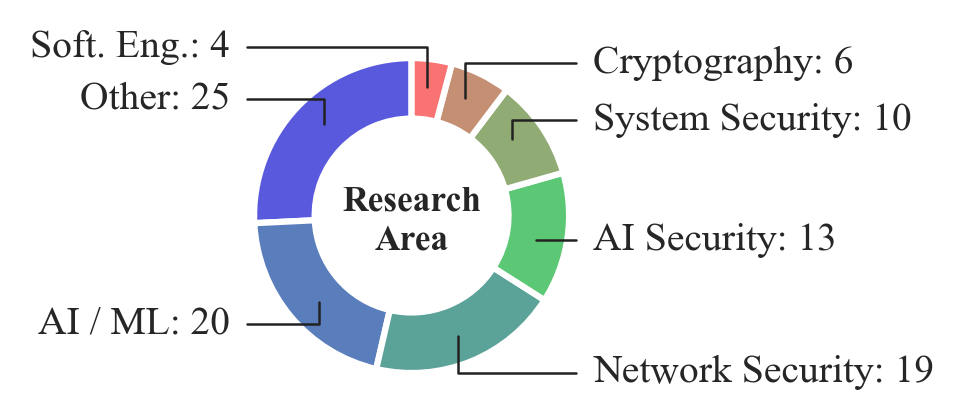

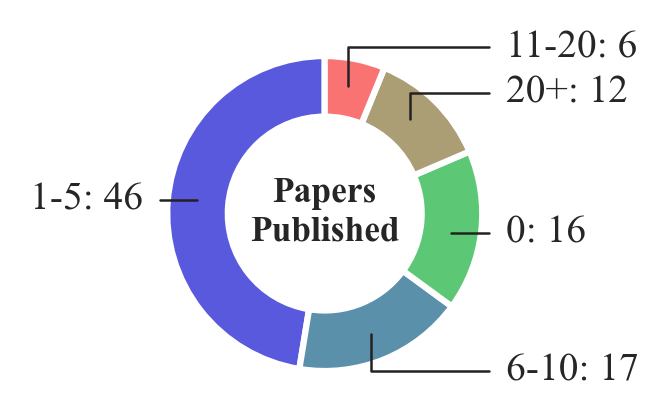

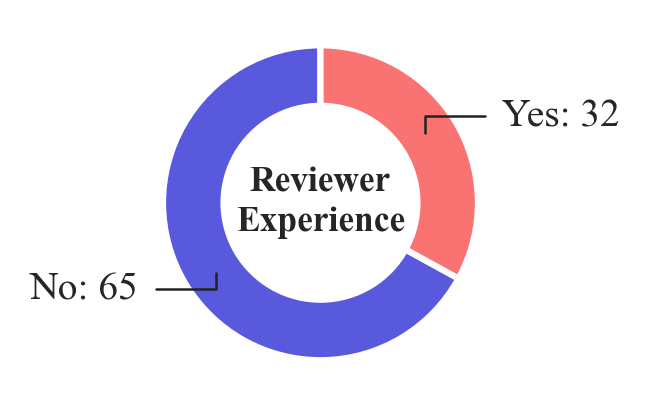

In [5]:
position_col = get_col('current academic position')
area_col = get_col('research area')
papers_col = get_col('peer-reviewed papers have you published')
native_col = get_col('English your native language')
reviewer_col = get_col('served as a reviewer')

position_counts = count_values(df[position_col]) if position_col else pd.Series(dtype=int)
area_counts = count_values(df[area_col]) if area_col else pd.Series(dtype=int)
papers_counts = count_values(df[papers_col]) if papers_col else pd.Series(dtype=int)
native_counts = count_values(df[native_col]) if native_col else pd.Series(dtype=int)
reviewer_counts = count_values(df[reviewer_col]) if reviewer_col else pd.Series(dtype=int)

print('Position counts:\n', position_counts)
print('Area counts:\n', area_counts)

position_counts_renamed = position_counts.rename({
    'PhD Student': 'PhD',
    'Undergraduate student': 'Undergraduate',
    'Faculty (Professor/Lecturer)': 'Faculty',
    "Master's Student": 'Master',
})
plot_pie(
    position_counts_renamed,
    'Academic\nPosition',
    'figs/profile_position.png',
    max_label_len=32,
    top_n=None,
    figsize=(2, 1.5),
    legend_right=True,
    legend_text=False,
    )
area_counts_renamed = area_counts.rename({
    'AI & Machine Learning': 'AI / ML',
    'Software Engineering': 'Soft. Eng.',
})
plot_pie(
    area_counts_renamed,
    'Research\nArea',
    'figs/profile_area.png',
    top_n=None,
    max_label_len=32,
    figsize=(2, 1.5),
    legend_right=True,
    legend_text=False,
    )
plot_pie(
    papers_counts,
    'Papers\nPublished',
    'figs/profile_papers.png',
    top_n=None,
    max_label_len=22,
    figsize=(2, 1.5),
    legend_right=True,
    legend_text=False,
    )
# plot_pie(
#     native_counts,
#     'Top-Tier venues reviewer experience',
#     'figs/profile_native_english.pdf',
#     top_n=6,
#     max_label_len=22,
#     figsize=(2, 1.5),
#     legend_right=True,
#     legend_text=False,
#     )
plot_pie(
    reviewer_counts,
    'Reviewer\nExperience',
    'figs/profile_reviewer.png',
    top_n=None,
    max_label_len=22,
    figsize=(2, 1.5),
    legend_right=True,
    legend_text=False,
    )

## 4. AI Tool Usage

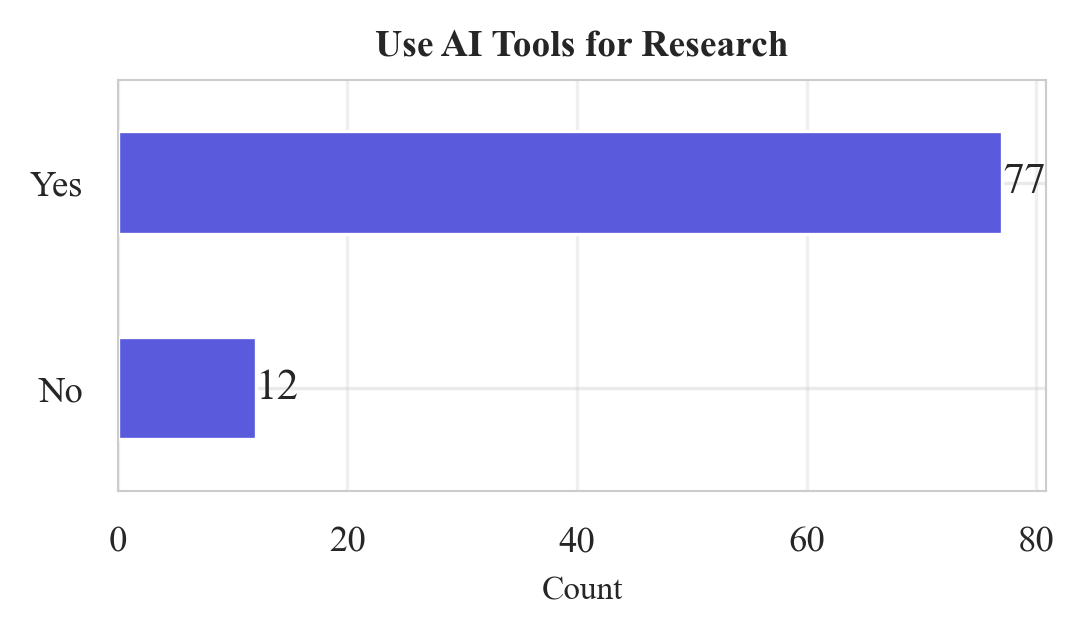

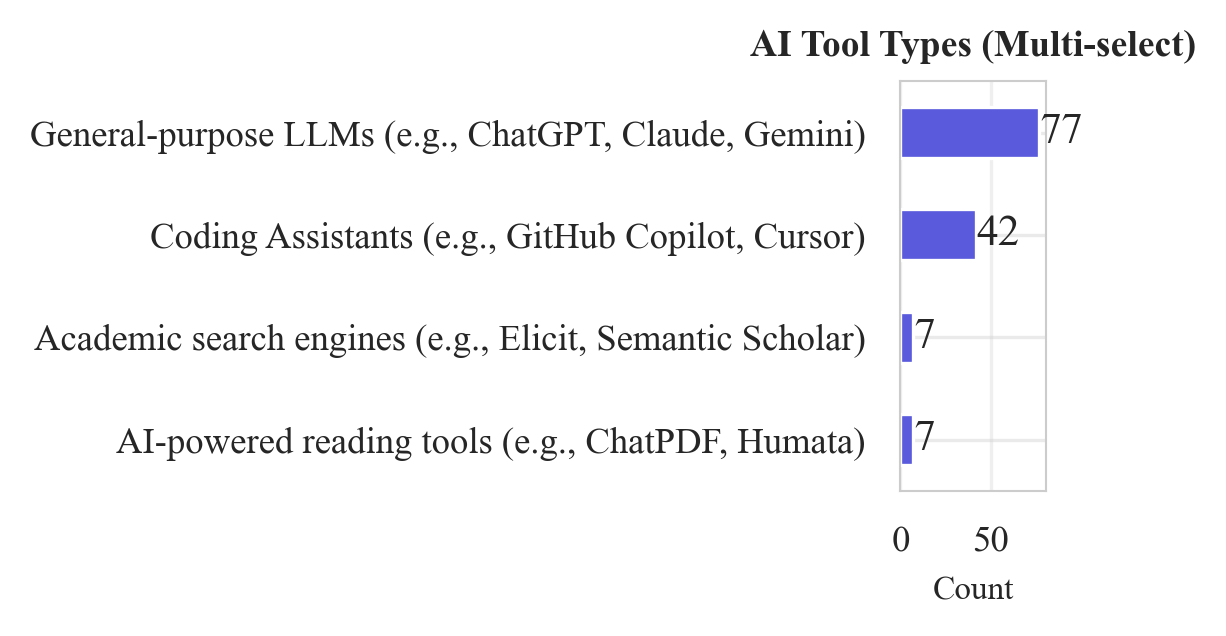

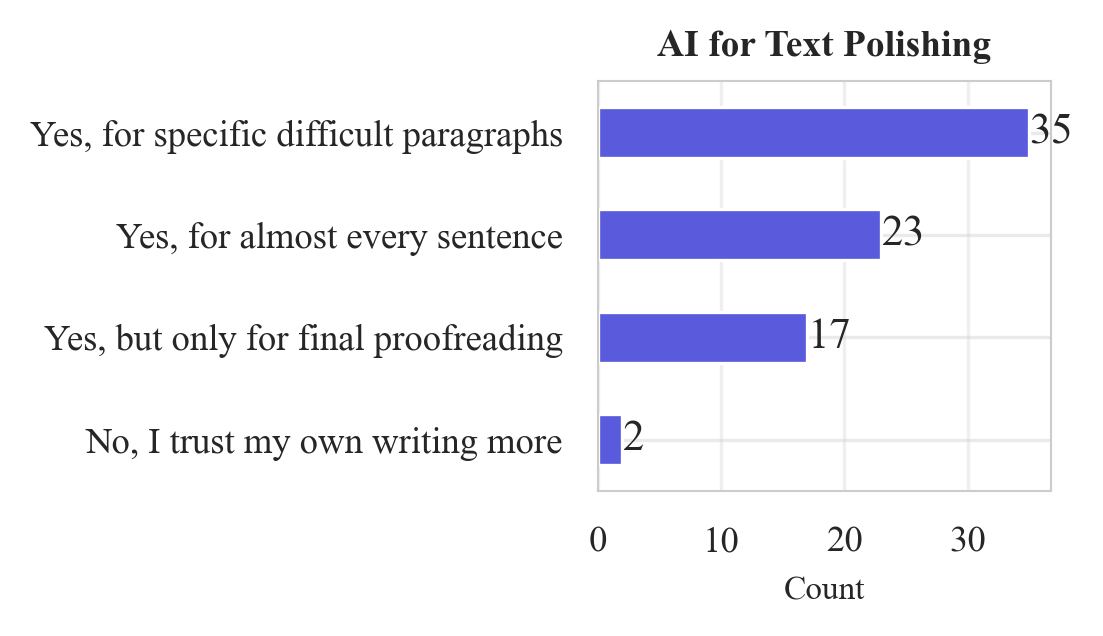

In [6]:
use_ai_col = get_col('Do you use AI-powered tools for research')
ai_types_col = get_col('Which types of AI-powered tools do you use for research')
text_polish_col = get_col('text polishing, grammar checking, or rephrasing')

use_ai_counts = count_values(df[use_ai_col]) if use_ai_col else pd.Series(dtype=int)
ai_types_counts = count_values(df[ai_types_col], multi=True) if ai_types_col else pd.Series(dtype=int)
text_polish_counts = count_values(df[text_polish_col]) if text_polish_col else pd.Series(dtype=int)

plot_bar(use_ai_counts, 'Use AI Tools for Research', 'figs/ai_use.pdf')
plot_barh(ai_types_counts, 'AI Tool Types (Multi-select)', 'figs/ai_tool_types.pdf')
plot_bar(text_polish_counts, 'AI for Text Polishing', 'figs/ai_text_polish.pdf')

## 5. Citation Integrity and Verification

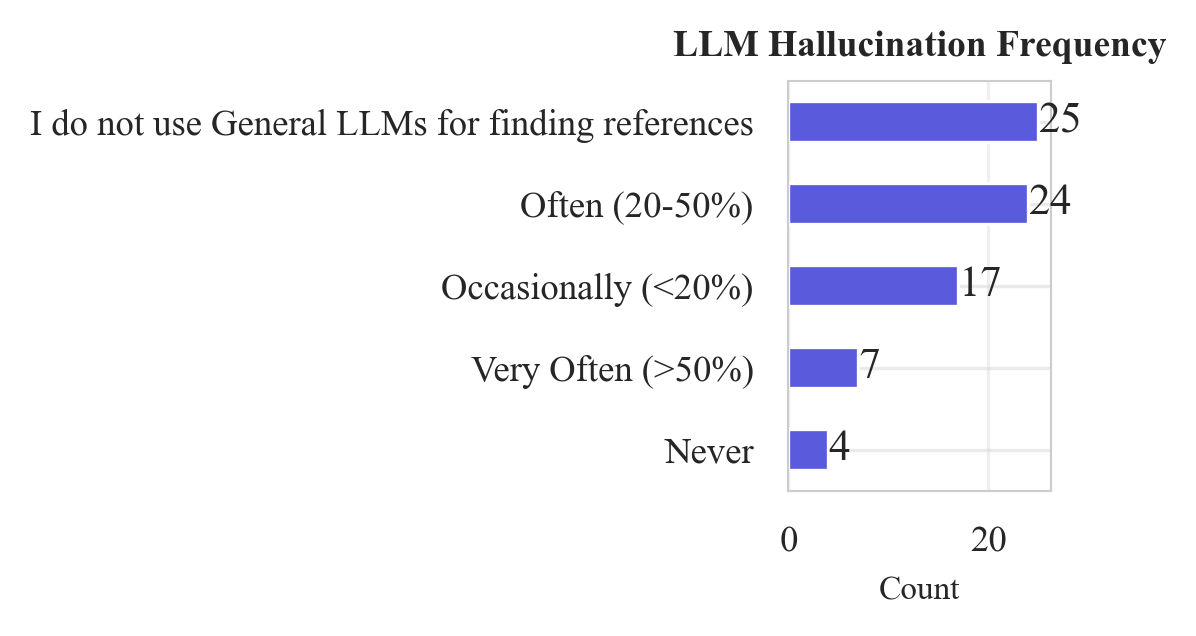

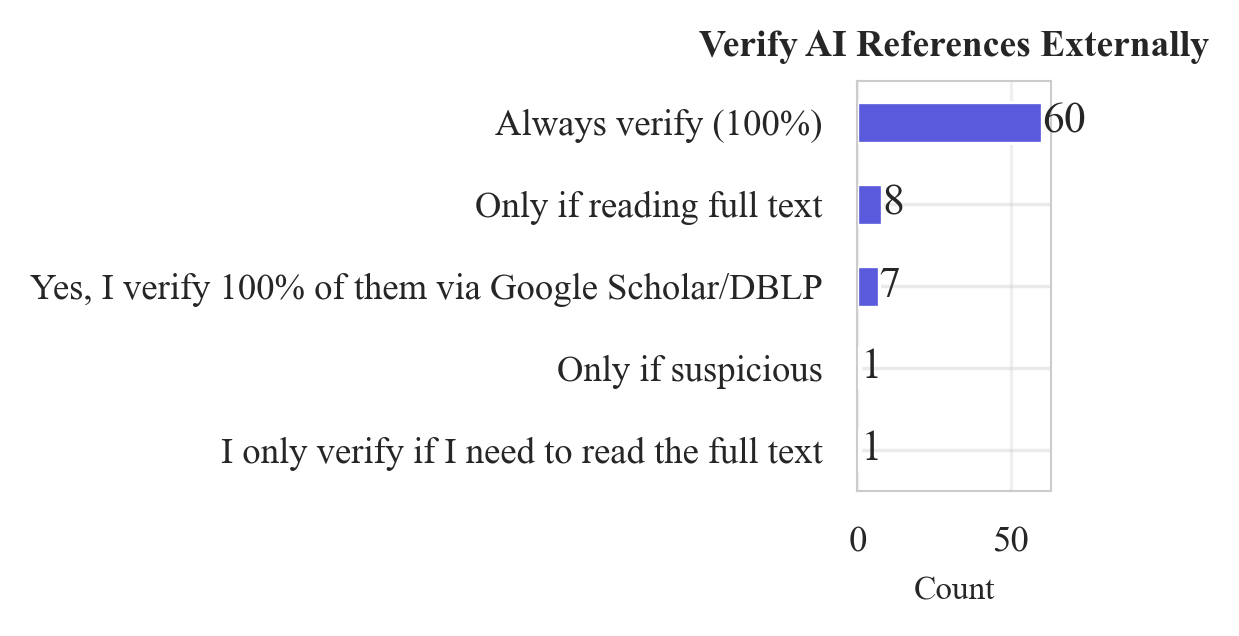

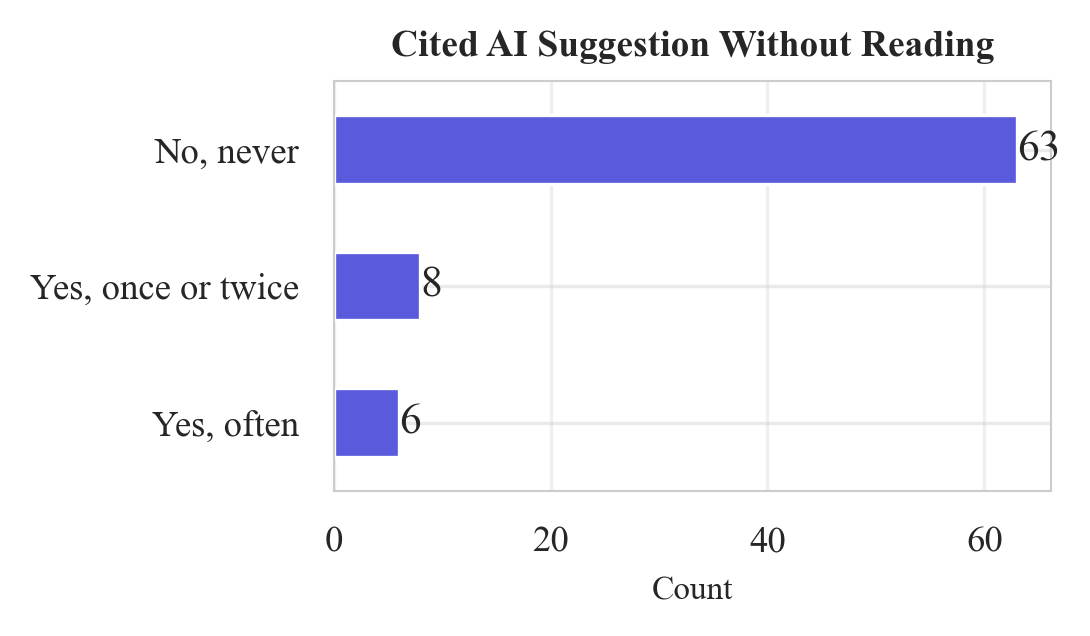

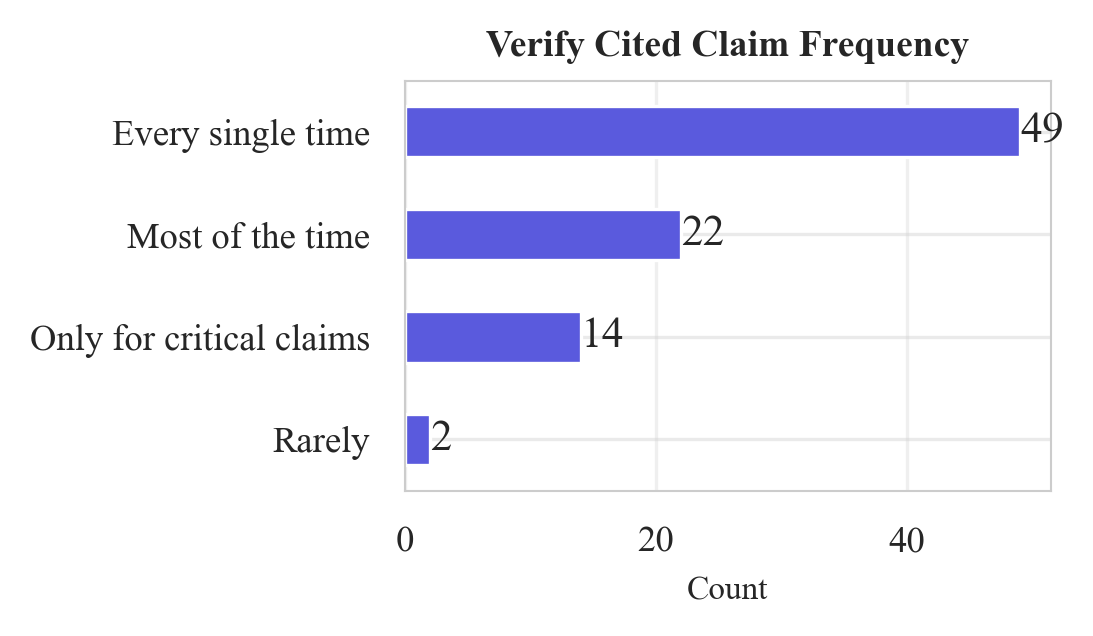

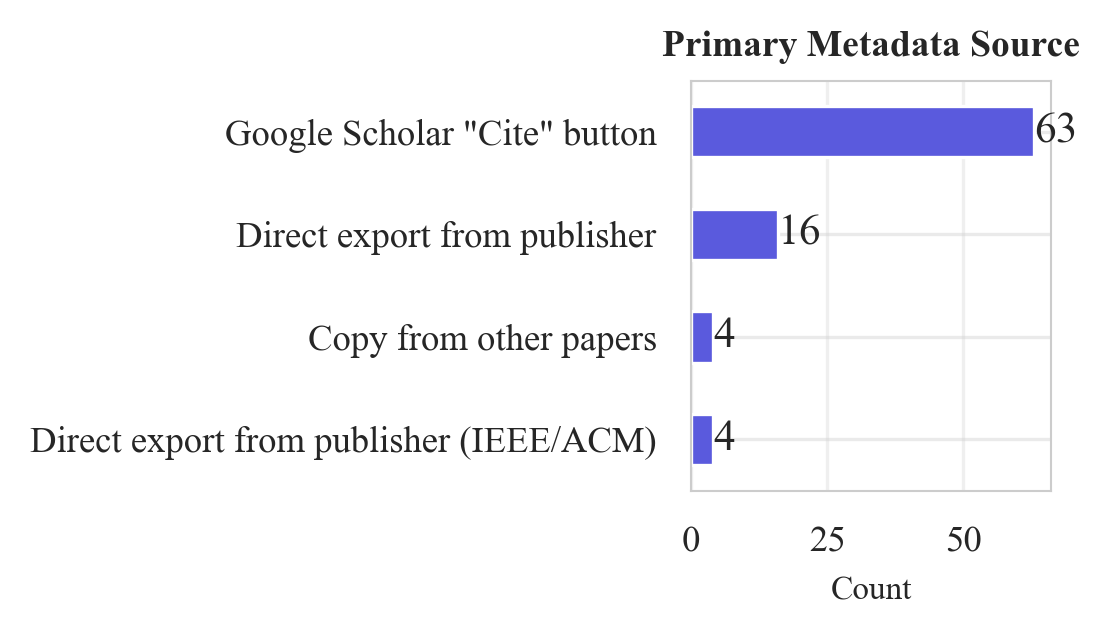

In [7]:
hallucination_col = get_col('hallucinations')
verify_external_col = get_col('do you still verify it externally')
cite_without_reading_col = get_col('cited a paper suggested by AI without reading')
verify_claim_col = get_col('verify that a cited paper actually contains the claim')
metadata_col = get_col('primary source of metadata')

hallucination_counts = count_values(df[hallucination_col]) if hallucination_col else pd.Series(dtype=int)
verify_external_counts = count_values(df[verify_external_col]) if verify_external_col else pd.Series(dtype=int)
cite_without_reading_counts = count_values(df[cite_without_reading_col]) if cite_without_reading_col else pd.Series(dtype=int)
verify_claim_counts = count_values(df[verify_claim_col]) if verify_claim_col else pd.Series(dtype=int)
metadata_counts = count_values(df[metadata_col]) if metadata_col else pd.Series(dtype=int)

plot_bar(hallucination_counts, 'LLM Hallucination Frequency', 'figs/citation_hallucination.pdf')
plot_bar(verify_external_counts, 'Verify AI References Externally', 'figs/citation_verify_external.pdf')
plot_bar(cite_without_reading_counts, 'Cited AI Suggestion Without Reading', 'figs/citation_without_reading.pdf')
plot_bar(verify_claim_counts, 'Verify Cited Claim Frequency', 'figs/citation_verify_claim.pdf')
plot_barh(metadata_counts, 'Primary Metadata Source', 'figs/citation_metadata_source.pdf')

## 6. Severity and Responsibility

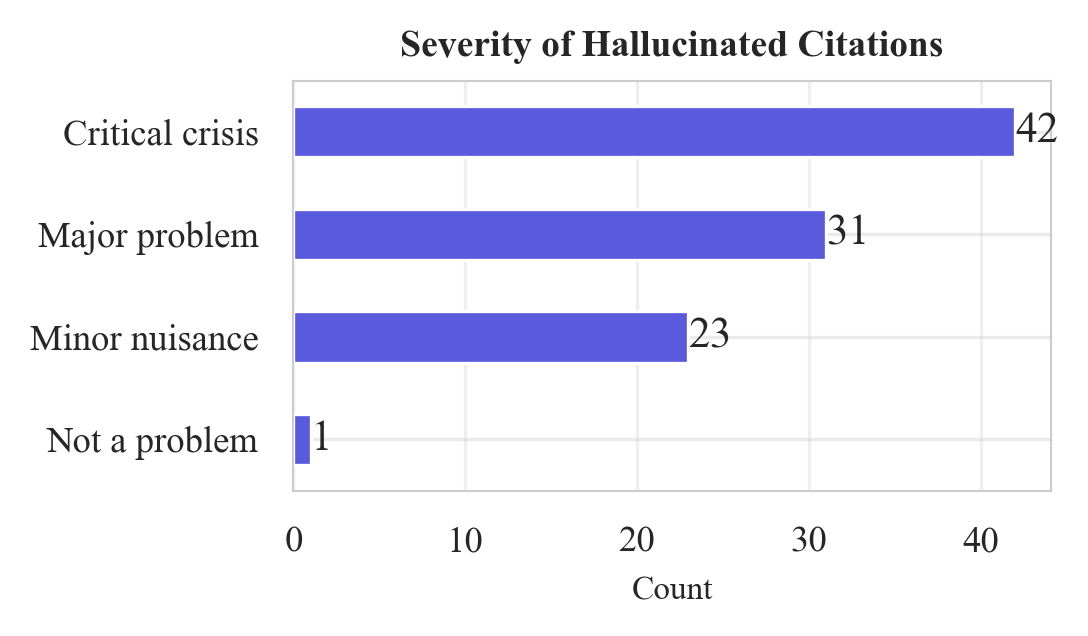

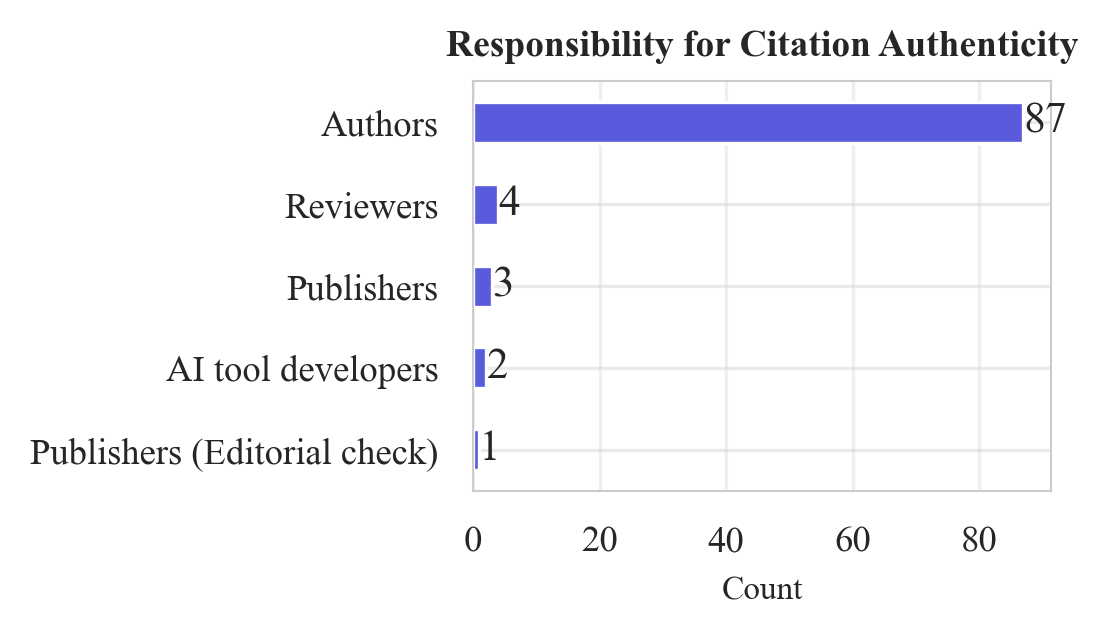

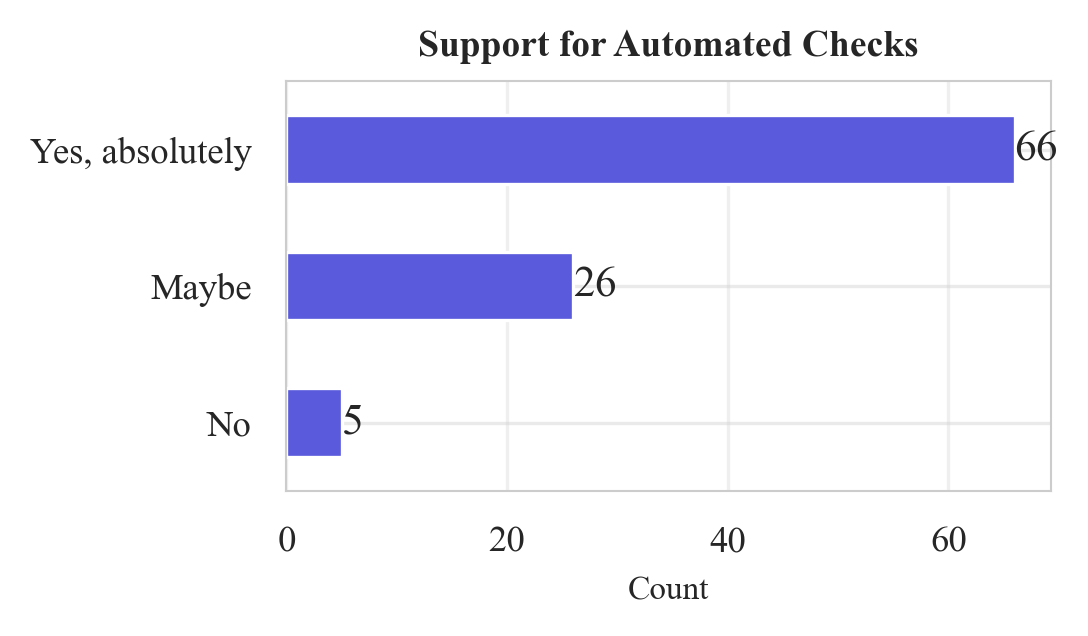

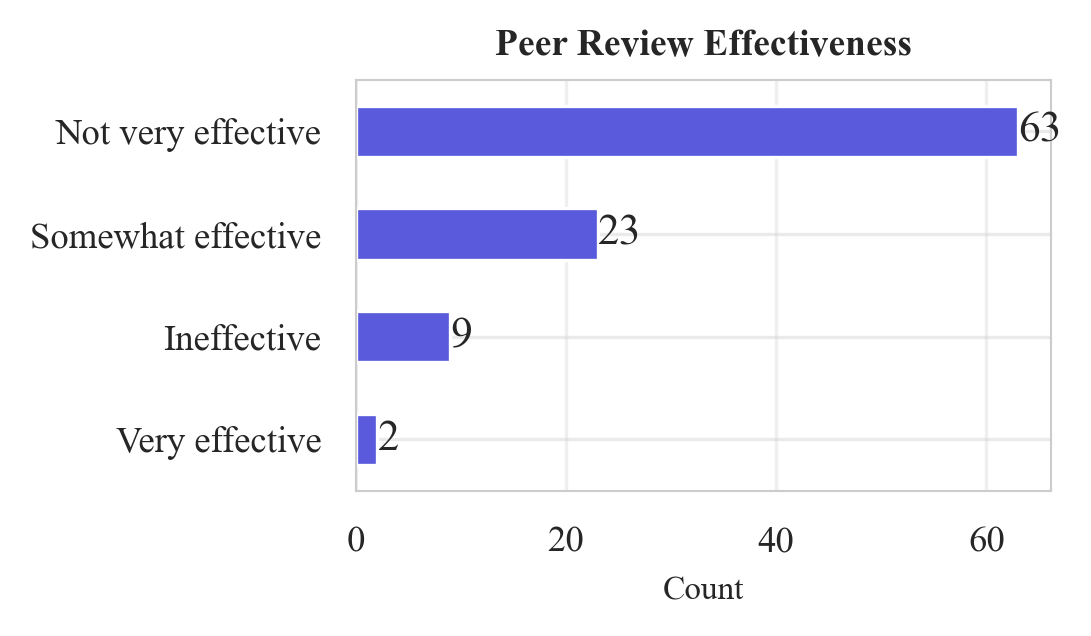

In [8]:
severity_col = get_col('How serious of an issue do you consider')
responsibility_col = get_col('primarily responsible for verifying')
automated_col = get_col('deploy automated tools')
peer_review_effective_col = get_col('peer review process is effective')

severity_counts = count_values(df[severity_col]) if severity_col else pd.Series(dtype=int)
responsibility_counts = count_values(df[responsibility_col]) if responsibility_col else pd.Series(dtype=int)
automated_counts = count_values(df[automated_col]) if automated_col else pd.Series(dtype=int)
peer_review_counts = count_values(df[peer_review_effective_col]) if peer_review_effective_col else pd.Series(dtype=int)

plot_bar(severity_counts, 'Severity of Hallucinated Citations', 'figs/issue_severity.pdf')
plot_barh(responsibility_counts, 'Responsibility for Citation Authenticity', 'figs/issue_responsibility.pdf')
plot_bar(automated_counts, 'Support for Automated Checks', 'figs/issue_automated_tools.pdf')
plot_bar(peer_review_counts, 'Peer Review Effectiveness', 'figs/issue_peer_review.pdf')

## 7. Reviewer Behavior (If Applicable)

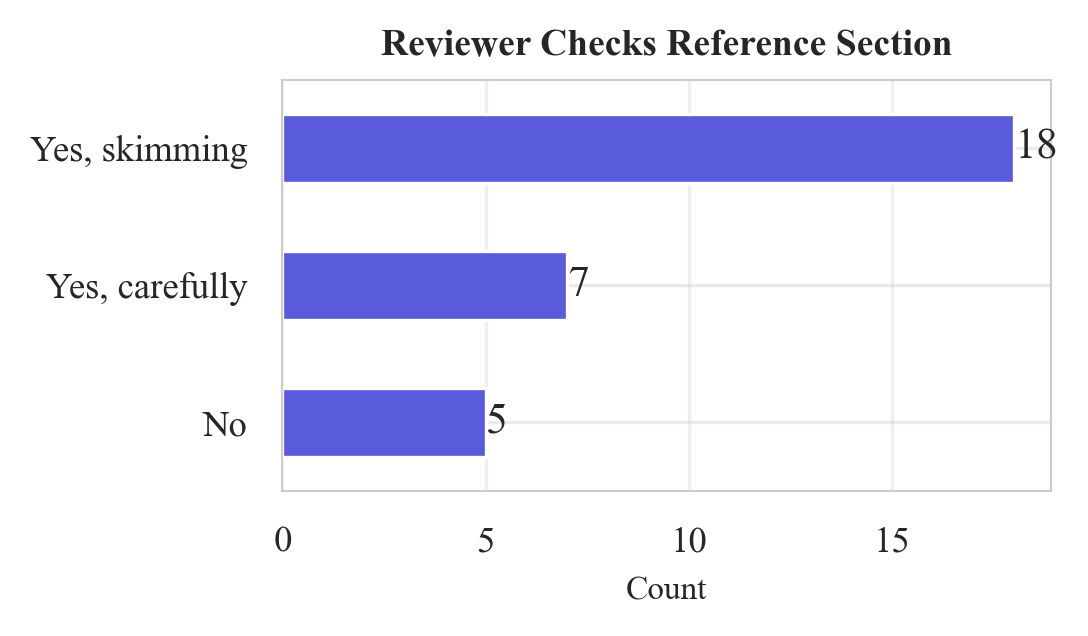

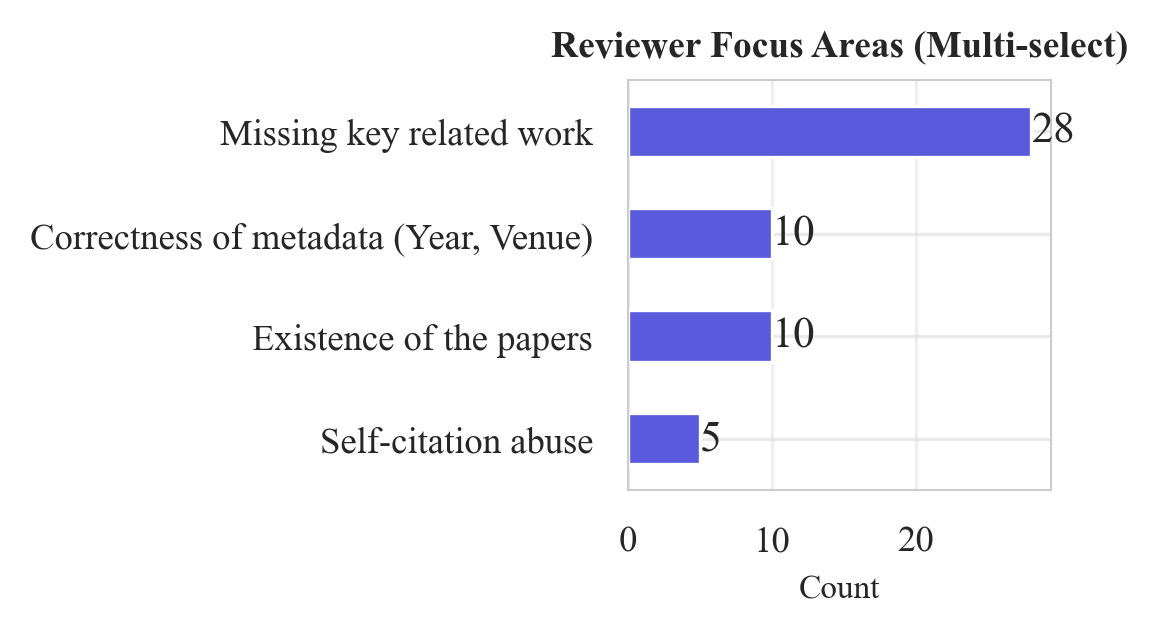

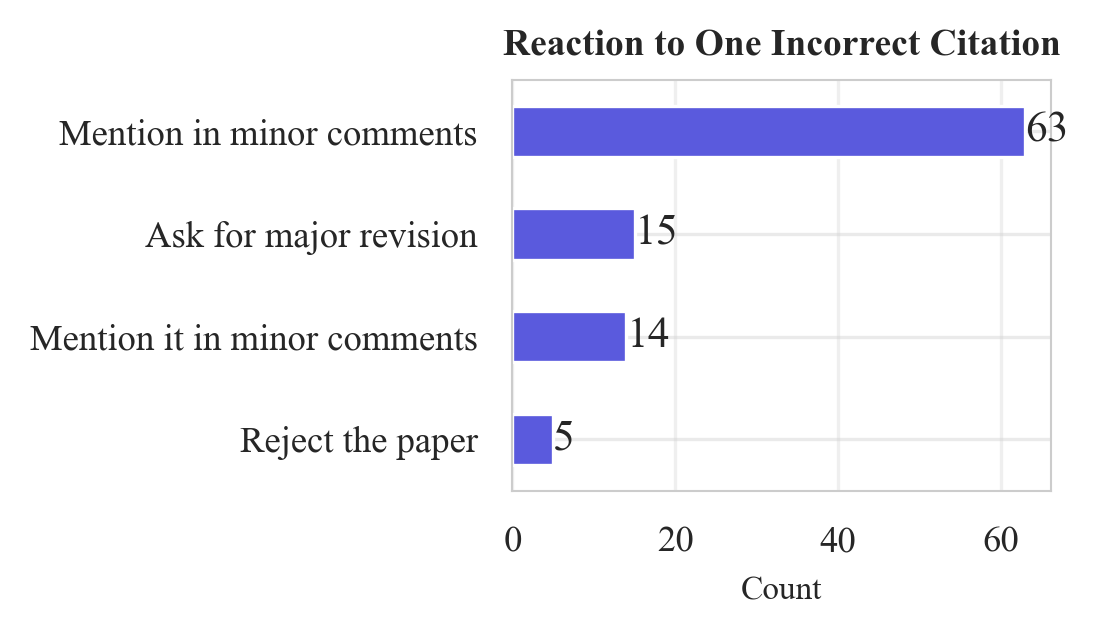

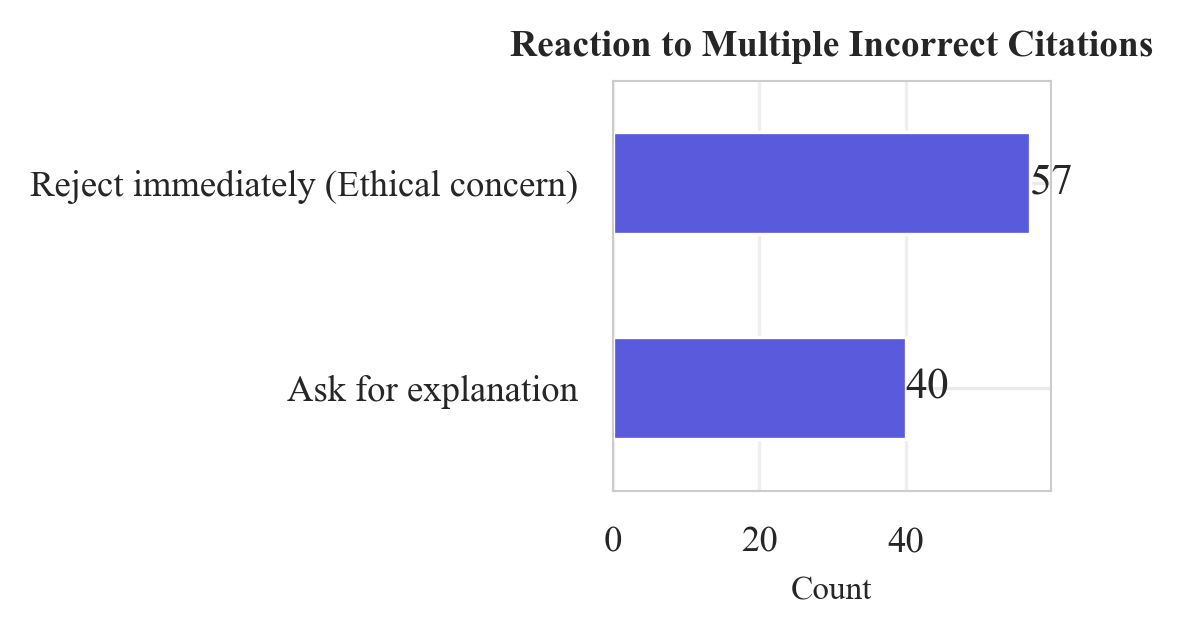

In [9]:
review_check_col = get_col('explicitly check the Reference section')
review_look_col = get_col('looking for when checking references')
reaction_one_col = get_col('reaction if you find one incorrect citation')
reaction_multi_col = get_col('reaction if you find multiple')

review_check_counts = count_values(df[review_check_col]) if review_check_col else pd.Series(dtype=int)
review_look_counts = count_values(df[review_look_col], multi=True) if review_look_col else pd.Series(dtype=int)
reaction_one_counts = count_values(df[reaction_one_col]) if reaction_one_col else pd.Series(dtype=int)
reaction_multi_counts = count_values(df[reaction_multi_col]) if reaction_multi_col else pd.Series(dtype=int)

plot_bar(review_check_counts, 'Reviewer Checks Reference Section', 'figs/reviewer_check_refs.pdf')
plot_barh(review_look_counts, 'Reviewer Focus Areas (Multi-select)', 'figs/reviewer_focus.pdf')
plot_barh(reaction_one_counts, 'Reaction to One Incorrect Citation', 'figs/reviewer_reaction_one.pdf')
plot_barh(reaction_multi_counts, 'Reaction to Multiple Incorrect Citations', 'figs/reviewer_reaction_multi.pdf')

## 7.5 All Questions Summary (Auto)

All questions analyzed: 41
Auto plots generated: 41
Plotting overview Q1: What is your current academic position?
Plotting overview Q2: Which research area best describes your work?
Plotting overview Q3: How many peer-reviewed papers have you published in your career?
Plotting overview Q4: Have you served as a reviewer for top-tier conferences (e.g., USENIX Sec, CCS, S&P, CVPR, NeurIPS) in the last 3 years?
Plotting overview Q5: Which stage of paper writing do you find most time-consuming? (Select up to 2).1
Plotting overview Q6: How do you typically search for related work?.1
Plotting overview Q7: Do you use AI-powered tools for research?.1
Plotting overview Q8: Which types of AI-powered tools do you use for research? (Select all that apply).1
Plotting overview Q9: Do you use AI tools specifically for text polishing, grammar checking, or rephrasing?.1
Plotting overview Q10: Specifically regarding CITATIONS, how do you use AI tools? (Select all that apply).1
Plotting overview Q11: When

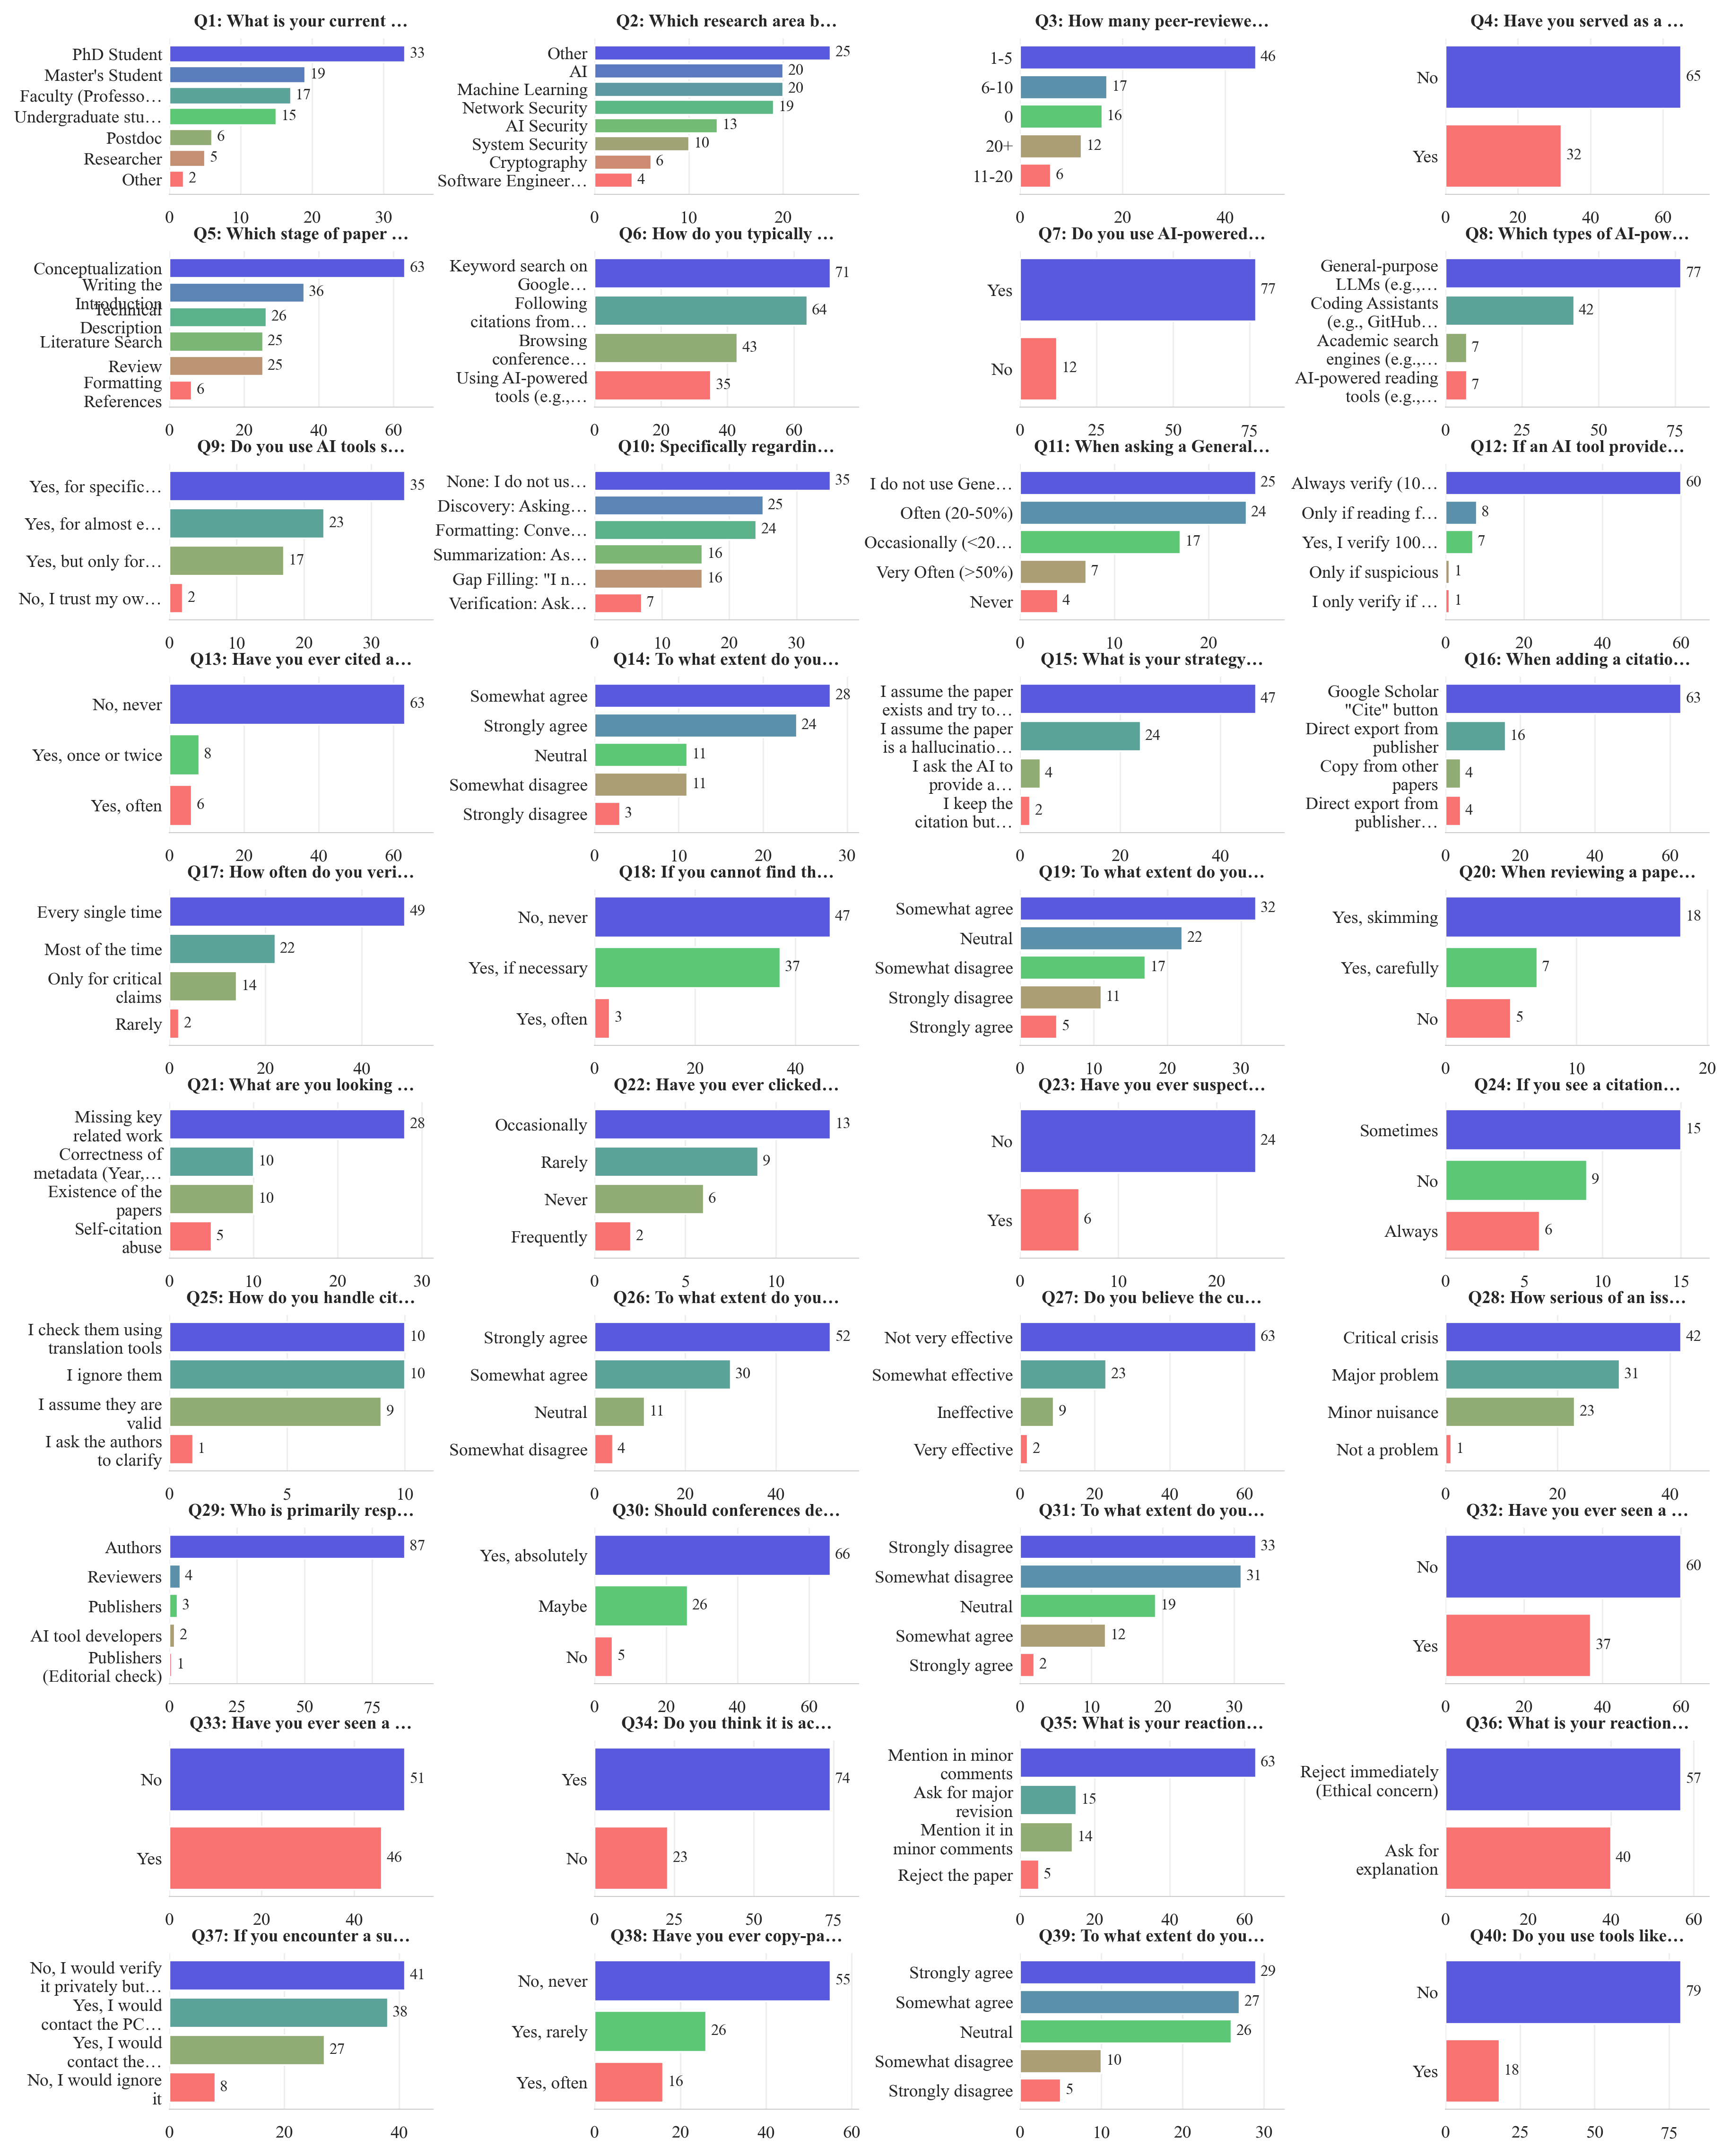

In [10]:
import math
import textwrap


def sanitize_filename(text):
    safe = re.sub(r'[^a-zA-Z0-9]+', '_', text.strip())
    return safe.strip('_')[:80] or 'question'


def shorten_title(text, max_len=35):
    text = str(text).strip()
    return text if len(text) <= max_len else text[:max_len - 1] + '…'


def shorten_label(text, max_len=48):
    text = str(text).strip()
    return text if len(text) <= max_len else text[:max_len - 1] + '…'


def wrap_label(text, max_len=18, max_lines=2):
    text = str(text).strip()
    if not text:
        return text
    lines = textwrap.wrap(
        text,
        width=max_len,
        break_long_words=False,
        break_on_hyphens=False,
    )
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        last = lines[-1]
        if len(last) >= max_len:
            lines[-1] = last[:max_len - 1] + '…'
        else:
            lines[-1] = last + '…'
    return '\n'.join(lines)


def should_wrap_labels(col_name, q_number):
    no_wrap_numbers = {1, 2, 10, 12, 13}
    no_wrap_keywords = [
        'do you use ai-powered tools for research',
        'do you use ai tools specifically for text polishing',
        'specifically','If an'
    ]
    if q_number in no_wrap_numbers:
        return False
    name = str(col_name).lower()
    if any(k in name for k in no_wrap_keywords):
        return False
    return True


def is_free_text_column(col_name, series):
    name = str(col_name).lower()
    if 'additional comments' in name or 'comments' in name or 'comment' in name:
        return True
    if '补充' in name or '备注' in name:
        return True
    non_empty = series.dropna().astype(str)
    if non_empty.empty:
        return False
    unique = non_empty.nunique()
    mean_len = non_empty.str.len().mean()
    return unique > 30 and mean_len > 40


def is_multi_select(col_name, series):
    name = str(col_name).lower()
    force_multi_keywords = [
        'do you report it',
    ]
    if any(k in name for k in force_multi_keywords):
        return True
    if 'select all' in name or 'select up to' in name:
        return True
    if '(select all that apply)' in name:
        return True
    for val in series.dropna().astype(str):
        if any(sep in val for sep in [' & ', ';', '；', '\n', '|', '、']):
            return True
    return False


def annotate_barh(ax, values, fontsize=10.5):
    max_val = max(values) if len(values) else 0
    offset = max_val * 0.02
    if max_val <= 0:
        offset = 0.5
        max_val = 1
    ax.set_xlim(0, max_val * 1.12)
    for i, val in enumerate(values):
        ax.text(val + offset, i, f'{int(val)}', va='center', ha='left', fontsize=fontsize)


def style_axis(ax):
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['right'].set_visible(False)


def get_overview_colors(n, use_gradient=True):
    if n <= 0:
        return []
    if not use_gradient:
        return [PALETTE[0]] * n
    return list(reversed(triad_gradient(n)))


def style_overview_axis(ax):
    ax.grid(True, axis='x', alpha=0.3)
    ax.grid(False, axis='y')
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.tick_params(axis='y', length=0)


OVERVIEW_USE_GRADIENT = True


all_question_stats = []
all_question_plots = []
plot_dir = 'figs/all_questions'
os.makedirs(plot_dir, exist_ok=True)


exclude_cols = set([consent_col]) if consent_col else set()
exclude_cols.update(['Index', 'is_conflict'])


include_native_in_overview = False
skip_overview_cols = set(['verify_norm', 'copy_norm'])
if not include_native_in_overview and native_col:
    skip_overview_cols.add(native_col)


question_labels = []


for col in df.columns:
    if col in exclude_cols:
        continue


    series = df[col]
    if series.dropna().empty:
        continue


    free_text = is_free_text_column(col, series)
    multi = False if free_text else is_multi_select(col, series)


    if free_text:
        counts = pd.Series(dtype=int)
        total = int(series.dropna().shape[0])
        unique = int(series.dropna().astype(str).nunique())
    else:
        counts = count_values(series, multi=multi)
        total = int(counts.sum()) if not counts.empty else 0
        unique = int(series.dropna().astype(str).nunique())


    q_number = len(question_labels) + 1
    question_labels.append(col)


    all_question_stats.append({
        'question': col,
        'question_number': q_number,
        'multi': multi,
        'total': total,
        'unique': unique,
        'counts': counts,
        'free_text': free_text,
    })


    if not counts.empty and not free_text:
        top = counts.head(15)
        use_wrap = should_wrap_labels(col, q_number)
        if use_wrap:
            labels = [wrap_label(x, max_len=24) for x in top[::-1].index]
        else:
            labels = [shorten_label(x, max_len=24) for x in top[::-1].index]
        fig, ax = plt.subplots(figsize=(2, 1))
        ax.barh(labels, top[::-1].values, color=PALETTE[0])
        ax.set_title(f'Q{q_number}: {shorten_title(col)}')
        ax.set_xlabel('Count')
        style_axis(ax)
        annotate_barh(ax, top[::-1].values, fontsize=10.5)
        plt.tight_layout(pad=0.36)
        filename = f"{plot_dir}/{sanitize_filename(col)}.pdf"
        plt.savefig(filename, dpi=300)
        plt.close(fig)
        all_question_plots.append(filename)


print('All questions analyzed:', len(all_question_stats))
print('Auto plots generated:', len(all_question_plots))


# One big figure with all questions as subplots
plot_items = [
    item for item in all_question_stats
    if not item['free_text']
    and not item['counts'].empty
    and item['question'] not in skip_overview_cols
 ]
if plot_items:
    n = len(plot_items)
    ncols = 4
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 1.5 * nrows))
    axes = np.atleast_2d(axes)


    for idx, item in enumerate(plot_items):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]
        counts = item['counts']
        use_wrap = should_wrap_labels(item['question'], item['question_number'])
        if use_wrap:
            labels = [wrap_label(x, max_len=18) for x in counts[::-1].index]
        else:
            labels = [shorten_label(x, max_len=18) for x in counts[::-1].index]
        overview_number = idx + 1
        colors = get_overview_colors(len(counts), OVERVIEW_USE_GRADIENT)
        ax.barh(labels, counts[::-1].values, color=colors)
        ax.set_title(f"Q{overview_number}: {shorten_title(item['question'], max_len=22)}", fontsize=9)
        print('Plotting overview Q{}: {}'.format(overview_number, item['question']))
        ax.set_xlabel('')
        ax.set_ylabel('')
        style_overview_axis(ax)
        ax.tick_params(axis='x', labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
        annotate_barh(ax, counts[::-1].values, fontsize=8)


    # Turn off unused axes
    for idx in range(n, nrows * ncols):
        r = idx // ncols
        c = idx % ncols
        axes[r, c].axis('off')


    plt.subplots_adjust(wspace=0.5, hspace=0.8)
    plt.tight_layout(pad=0)
    plt.savefig('figs/all_questions_overview.pdf', dpi=300)
    plt.show()

## 7.6 Key Questions (2x2)

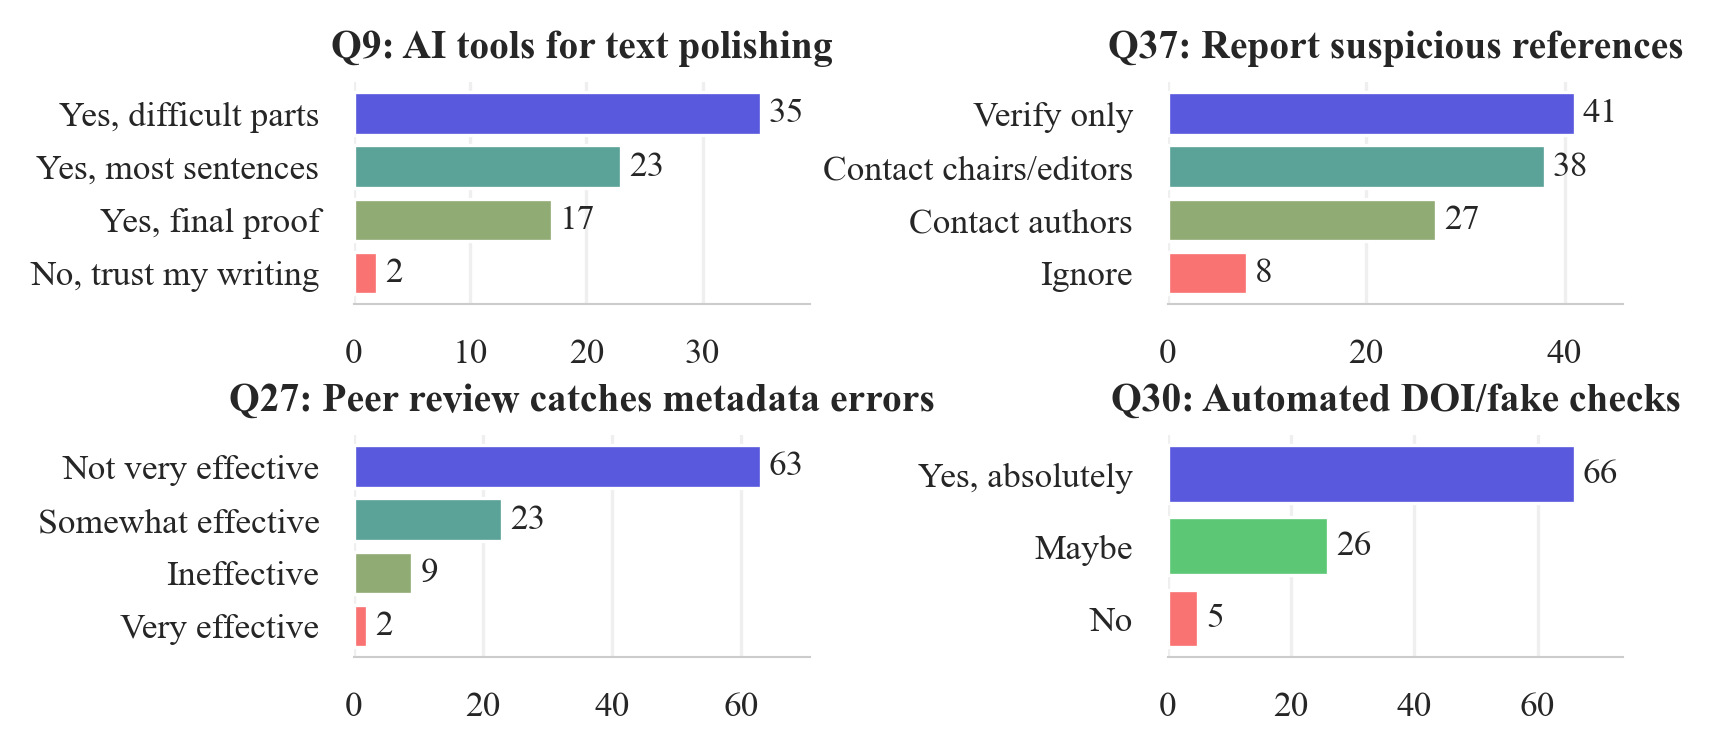

In [11]:
q_items = [
    (
        'Q9',
        'Do you use AI tools specifically for text polishing, grammar checking, or rephrasing?.1',
        False,
        'Q9: AI tools for text polishing',
    ),
    (
        'Q37',
        'If you encounter a suspicious or clearly fake reference in a published paper, do you report it?',
        True,
        'Q37: Report suspicious references',
    ),
    (
        'Q27',
        'Do you believe the current peer review process is effective at catching metadata errors in references?',
        False,
        'Q27: Peer review catches metadata errors',
    ),
    (
        'Q30',
        'Should conferences deploy automated tools to check for broken DOIs or fake references upon submission?',
        False,
        'Q30: Automated DOI/fake checks',
    ),
    ]

label_map_by_q = {
    'Q9': {
        'Yes, for specific difficult paragraphs': 'Yes, difficult parts',
        'Yes, for almost every sentence': 'Yes, most sentences',
        'Yes, but only for final proofreading': 'Yes, final proof',
        'No, I trust my own writing more': 'No, trust my writing',
    },
    'Q11': {
        'Very Often (>50%)': 'Very often',
        'Often (20-50%)': 'Often',
        'Occasionally (<20%)': 'Occasionally',
        "Don't use LLMs": 'No LLMs',
        'I do not use General LLMs for finding references': 'No LLMs',
    },
    'Q37': {
        'No, I would verify it privately but take no action': 'Verify only',
        'Yes, I would contact the PC Chairs or Journal Editors': 'Contact chairs/editors',
        'Yes, I would contact the authors directly': 'Contact authors',
        'No, I would ignore it': 'Ignore',
    },
}

def get_exact_col(df, text):
    if text in df.columns:
        return text
    return find_column(df, text)

def plot_question_barh(ax, series, title):
    if series is None or series.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        return
    counts = series.sort_values(ascending=True)
    colors = list(reversed(triad_gradient(len(counts))))
    bars = ax.barh(counts.index, counts.values, color=colors)
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel('', fontsize=9)
    ax.tick_params(axis='x', labelsize=8.5)
    ax.tick_params(axis='y', labelsize=8.5)
    style_axis(ax)
    ax.grid(True, axis='x')
    ax.grid(False, axis='y')
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    max_val = float(counts.max()) if len(counts) else 0.0
    if max_val <= 0:
        max_val = 1.0
    ax.set_xlim(0, max_val * 1.12)
    offset = max_val * 0.02
    for bar in bars:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(width + offset, y, f'{int(width)}', va='center', ha='left', fontsize=8.5)

setup_usenix_style()
fig, axes = plt.subplots(2, 2, figsize=(6*0.9, 3*0.8))
axes = axes.flatten()

for ax, (q_label, q_text, is_multi, q_title) in zip(axes, q_items):
    col = get_exact_col(df, q_text)
    series = count_values(df[col], multi=is_multi) if col else pd.Series(dtype=int)
    label_map = label_map_by_q.get(q_label, {})
    if label_map:
        series = series.rename(label_map)
    plot_question_barh(ax, series, q_title)

# Turn off any extra axes (if any)
for idx in range(len(q_items), len(axes)):
    axes[idx].axis('off')

plt.tight_layout(pad=0.4)
plt.savefig('figs/key_questions_2x2.pdf', dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

In [12]:
answered = df_all['verify_norm'].notna() & df_all['copy_norm'].notna()
conflict_n = int(df_all.loc[answered, 'is_conflict'].sum())
answered_n = int(answered.sum())

n_total_all = len(df_all)
n_total_valid = len(df)

summary = pd.DataFrame({
    'metric': ['total_rows', 'answered_both', 'conflict', 'valid_rows'],
    'count': [n_total_all, answered_n, conflict_n, n_total_valid],
})
summary

NameError: name 'df_all' is not defined

## 8. BibTeX Consistency Check (Conflict Rule)

In [ ]:
invalid_rows = df.loc[answered & df['is_conflict']].copy()
invalid_out = 'bibtex_conflict_invalid_rows.csv'
invalid_rows.to_csv(invalid_out, index=False)
print('Invalid rows saved to:', invalid_out)

Invalid rows saved to: bibtex_conflict_invalid_rows.csv


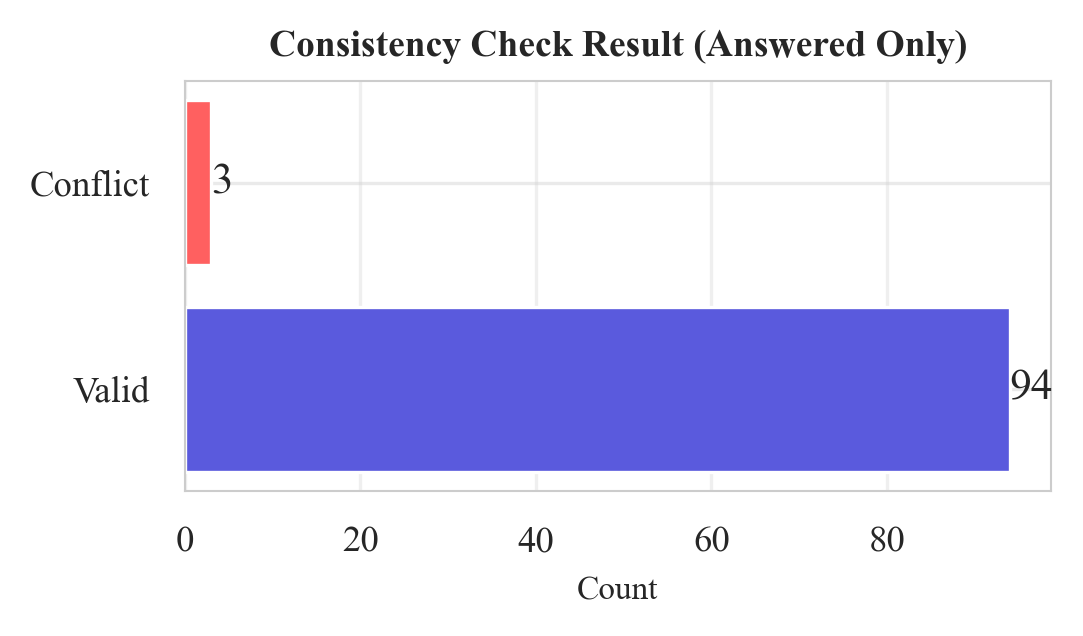

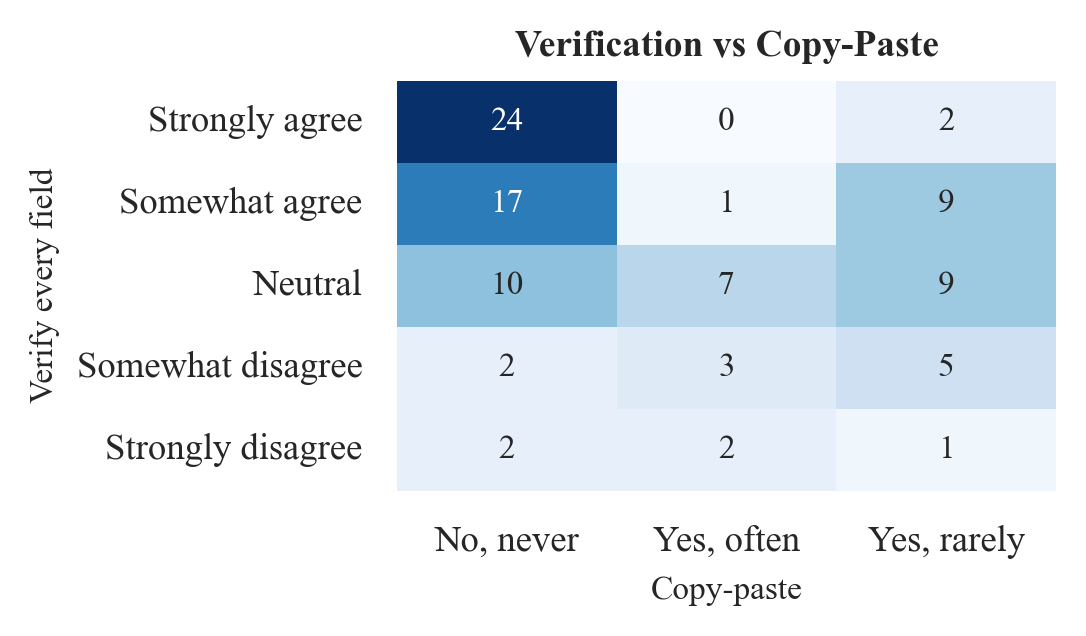

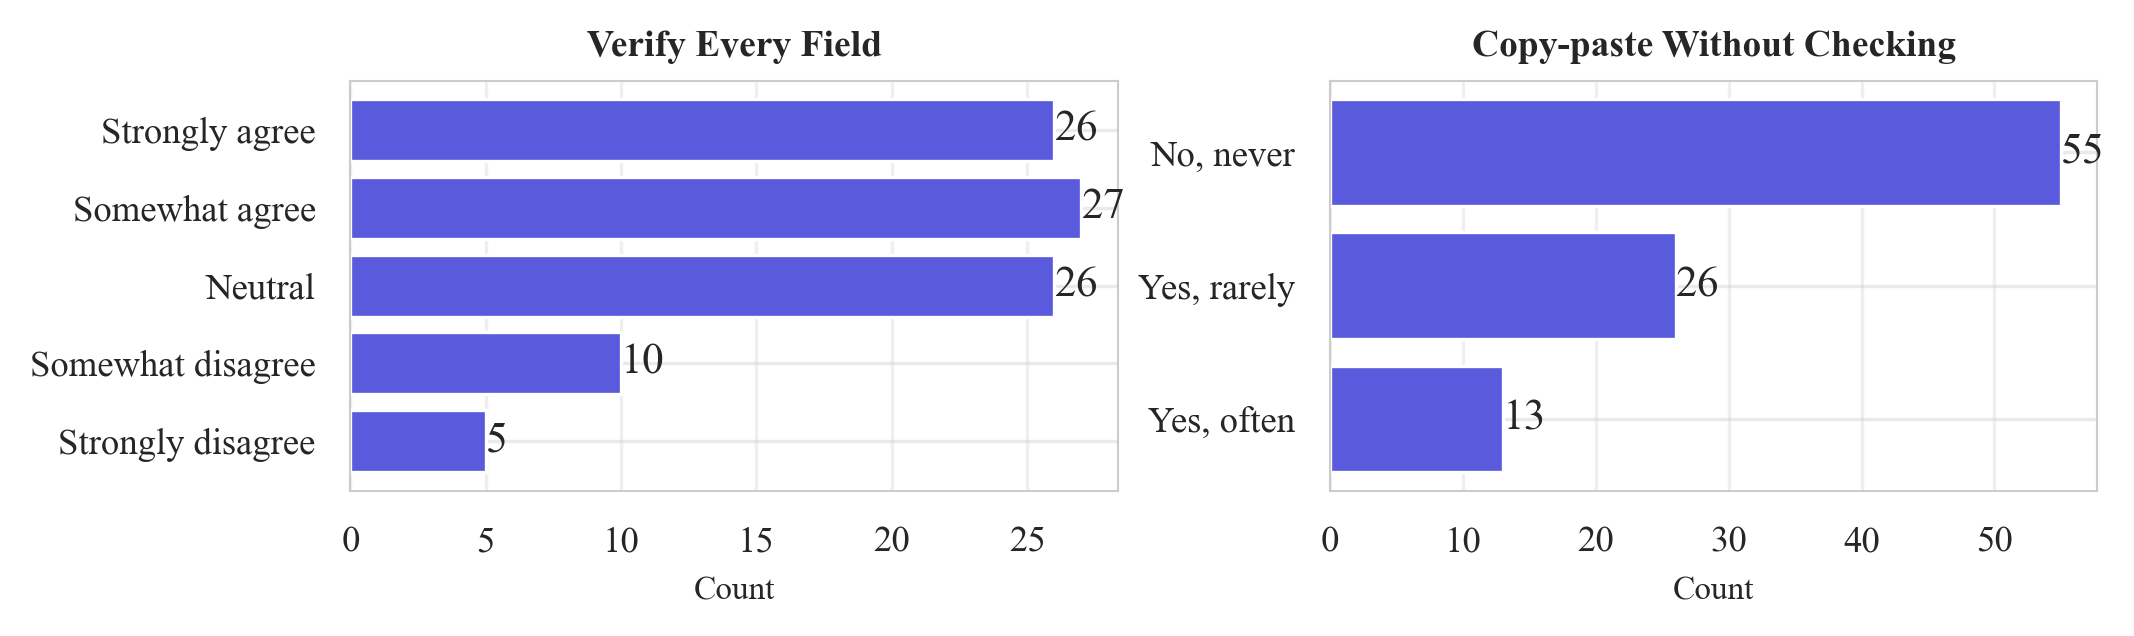

In [ ]:
# Plot 1: Valid vs Conflict (comparison)
fig, ax = plt.subplots(figsize=(3.5, 2))
ax.barh(['Valid', 'Conflict'], [n_total_valid, conflict_n], color=[PALETTE[0], PALETTE[1]])
ax.set_title('Consistency Check Result (Answered Only)')
ax.set_xlabel('Count')
ax.grid(True, axis='x', alpha=0.3)
for i, v in enumerate([n_total_valid, conflict_n]):
    ax.text(v, i, str(v), va='center', ha='left', fontsize=10.5)
plt.tight_layout(pad=0.36)
plt.savefig('figs/bibtex_conflict_summary.pdf', dpi=300)
plt.show()

# Plot 2: Crosstab heatmap
ct = pd.crosstab(
    df.loc[answered, 'verify_norm'],
    df.loc[answered, 'copy_norm'],
    dropna=False
).reindex(index=LIKERT_ORDER)

fig, ax = plt.subplots(figsize=(3.5, 2))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('Verification vs Copy-Paste')
ax.set_xlabel('Copy-paste')
ax.set_ylabel('Verify every field')
plt.tight_layout(pad=0.36)
plt.savefig('figs/bibtex_conflict_heatmap.pdf', dpi=300)
plt.show()

# Plot 3: Distributions (1x2)
fig, axes = plt.subplots(1, 2, figsize=(7, 2))

verify_counts = df['verify_norm'].value_counts().reindex(LIKERT_ORDER)
copy_counts = df['copy_norm'].value_counts()

axes[0].barh(verify_counts.index[::-1], verify_counts.values[::-1], color=PALETTE[0])
axes[0].set_title('Verify Every Field')
axes[0].set_xlabel('Count')
axes[0].grid(True, axis='x', alpha=0.3)
for i, val in enumerate(verify_counts.values[::-1]):
    axes[0].text(val, i, f'{int(val)}', va='center', ha='left', fontsize=10.5)

axes[1].barh(copy_counts.index[::-1], copy_counts.values[::-1], color=PALETTE[0])
axes[1].set_title('Copy-paste Without Checking')
axes[1].set_xlabel('Count')
axes[1].grid(True, axis='x', alpha=0.3)
for i, val in enumerate(copy_counts.values[::-1]):
    axes[1].text(val, i, f'{int(val)}', va='center', ha='left', fontsize=10.5)

plt.tight_layout(pad=0.36)
plt.savefig('figs/bibtex_conflict_distributions.pdf', dpi=300)
plt.show()

## 9. Key Findings (Auto Summary)

In [ ]:
def pct(count, base):
    return (count / base * 100) if base else 0

# Key metrics (after conflict removal)
n_total = len(df)

use_ai_yes = int(use_ai_counts.get('Yes', 0)) if not use_ai_counts.empty else 0
use_ai_base = int(use_ai_counts.sum()) if not use_ai_counts.empty else 0

hall_often = 0
if not hallucination_counts.empty:
    hall_often = hallucination_counts.get('Often (20-50%)', 0) + hallucination_counts.get('Very Often (>50%)', 0)
    hall_often += hallucination_counts.get('经常（20-50%）', 0) + hallucination_counts.get('非常频繁（>50% 的时间）', 0)
hall_base = int(hallucination_counts.sum()) if not hallucination_counts.empty else 0

verify_always = 0
if not verify_external_counts.empty:
    verify_always += verify_external_counts.get('Always verify (100%)', 0)
    verify_always += verify_external_counts.get('Yes, I verify 100% of them via Google Scholar/DBLP', 0)
    verify_always += verify_external_counts.get('是，我会通过谷歌学术/DBLP 100% 验证', 0)
verify_base = int(verify_external_counts.sum()) if not verify_external_counts.empty else 0

copy_yes = 0
if not df['copy_norm'].dropna().empty:
    copy_yes = int((df['copy_norm'].isin(['Yes, often', 'Yes, once or twice', 'Yes, rarely'])).sum())
copy_base = int(df['copy_norm'].notna().sum())

severity_major = 0
if not severity_counts.empty:
    severity_major += severity_counts.get('Major problem', 0) + severity_counts.get('Critical crisis', 0)
    severity_major += severity_counts.get('主要问题', 0) + severity_counts.get('严重危机', 0)
severity_base = int(severity_counts.sum()) if not severity_counts.empty else 0

auto_yes = 0
if not automated_counts.empty:
    auto_yes += automated_counts.get('Yes, absolutely', 0)
    auto_yes += automated_counts.get('是，绝对应该', 0)
auto_base = int(automated_counts.sum()) if not automated_counts.empty else 0

print('Key findings (counts and %):')
print(f'- AI tool usage: {use_ai_yes}/{use_ai_base} ({pct(use_ai_yes, use_ai_base):.1f}%)')
print(f'- Hallucination often/very often: {hall_often}/{hall_base} ({pct(hall_often, hall_base):.1f}%)')
print(f'- Always verify AI references: {verify_always}/{verify_base} ({pct(verify_always, verify_base):.1f}%)')
print(f'- Copy-paste BibTeX without checking (any): {copy_yes}/{copy_base} ({pct(copy_yes, copy_base):.1f}%)')
print(f'- Severity major/critical: {severity_major}/{severity_base} ({pct(severity_major, severity_base):.1f}%)')
print(f'- Support automated checks (Yes, absolutely): {auto_yes}/{auto_base} ({pct(auto_yes, auto_base):.1f}%)')
print(f'- BibTeX conflict rate: {conflict_n}/{answered_n} ({pct(conflict_n, answered_n):.1f}%)')
print(f'- Valid rows used for analysis: {n_total}/{n_total_all}')

Key findings (counts and %):
- AI tool usage: 75/86 (87.2%)
- Hallucination often/very often: 31/75 (41.3%)
- Always verify AI references: 65/75 (86.7%)
- Copy-paste BibTeX without checking (any): 39/94 (41.5%)
- Severity major/critical: 72/94 (76.6%)
- Support automated checks (Yes, absolutely): 66/94 (70.2%)
- BibTeX conflict rate: 3/97 (3.1%)
- Valid rows used for analysis: 94/97


In [ ]:
report_path = 'bibtex_conflict_report.md'


def append_series(lines, title, series, total=None):
    if series is None or series.empty:
        return
    lines.append(f'### {title}')
    for k, v in series.items():
        if total:
            lines.append(f'- {k}: {v} ({pct(v, total):.1f}%)')
        else:
            lines.append(f'- {k}: {v}')
    lines.append('')


def append_all_questions(lines, stats):
    lines.append('## All Questions (Full Statistics)')
    for item in stats:
        question = item['question']
        counts = item['counts']
        total = item['total']
        unique = item['unique']
        multi = item['multi']
        free_text = item['free_text']

        lines.append(f'### {question}')
        lines.append(f'- Responses: {total} | Unique: {unique} | Multi-select: {multi}')

        if free_text:
            non_empty = df[question].dropna().astype(str)
            lines.append(f'- Free-text responses: {non_empty.shape[0]}')
            if not non_empty.empty:
                response_counts = non_empty.value_counts()
                for resp, cnt in response_counts.items():
                    lines.append(f'- {resp}: {cnt}')
            lines.append('')
            continue

        if counts.empty:
            lines.append('- No valid responses')
            lines.append('')
            continue

        for k, v in counts.items():
            lines.append(f'- {k}: {v} ({pct(v, total):.1f}%)')
        lines.append('')


lines = []
lines.append('# Survey Analysis Report (Merged.csv)')
lines.append('')
lines.append('## Data Summary')
lines.append(f'- Total rows after cleaning/consent: {n_total_all}')
lines.append(f'- Conflict samples removed: {conflict_n}')
lines.append(f'- Valid rows used for analysis: {n_total}')
lines.append(f'- Answered both BibTeX questions: {answered_n}')
lines.append('')

lines.append('## Key Findings')
lines.append(f'- AI tool usage: {use_ai_yes}/{use_ai_base} ({pct(use_ai_yes, use_ai_base):.1f}%)')
lines.append(f'- Hallucination often/very often: {hall_often}/{hall_base} ({pct(hall_often, hall_base):.1f}%)')
lines.append(f'- Always verify AI references: {verify_always}/{verify_base} ({pct(verify_always, verify_base):.1f}%)')
lines.append(f'- Copy-paste BibTeX without checking (any): {copy_yes}/{copy_base} ({pct(copy_yes, copy_base):.1f}%)')
lines.append(f'- Severity major/critical: {severity_major}/{severity_base} ({pct(severity_major, severity_base):.1f}%)')
lines.append(f'- Support automated checks (Yes, absolutely): {auto_yes}/{auto_base} ({pct(auto_yes, auto_base):.1f}%)')
lines.append(f'- BibTeX conflict rate: {conflict_n}/{answered_n} ({pct(conflict_n, answered_n):.1f}%)')
lines.append('')

lines.append('## Worth Highlighting')
lines.append('- Compare high AI adoption with verification behavior to assess risk exposure.')
lines.append('- Hallucination rates can be contrasted with "always verify" rates to quantify gaps.')
lines.append('- BibTeX conflict samples show potential self-report inconsistency worth qualitative follow-up.')
lines.append('- Severity perception vs support for automated tools signals policy readiness.')
lines.append('')

lines.append('## Demographics')
append_series(lines, 'Academic Position', position_counts, total=position_counts.sum() if not position_counts.empty else None)
append_series(lines, 'Research Area', area_counts, total=area_counts.sum() if not area_counts.empty else None)
append_series(lines, 'Papers Published', papers_counts, total=papers_counts.sum() if not papers_counts.empty else None)
append_series(lines, 'Native English', native_counts, total=native_counts.sum() if not native_counts.empty else None)
append_series(lines, 'Reviewer Experience', reviewer_counts, total=reviewer_counts.sum() if not reviewer_counts.empty else None)

lines.append('## AI Tool Usage')
append_series(lines, 'Use AI Tools for Research', use_ai_counts, total=use_ai_counts.sum() if not use_ai_counts.empty else None)
append_series(lines, 'AI Tool Types (Multi-select)', ai_types_counts)
append_series(lines, 'AI for Text Polishing', text_polish_counts, total=text_polish_counts.sum() if not text_polish_counts.empty else None)

lines.append('## Citation Integrity and Verification')
append_series(lines, 'LLM Hallucination Frequency', hallucination_counts, total=hallucination_counts.sum() if not hallucination_counts.empty else None)
append_series(lines, 'Verify AI References Externally', verify_external_counts, total=verify_external_counts.sum() if not verify_external_counts.empty else None)
append_series(lines, 'Cited AI Suggestion Without Reading', cite_without_reading_counts, total=cite_without_reading_counts.sum() if not cite_without_reading_counts.empty else None)
append_series(lines, 'Verify Cited Claim Frequency', verify_claim_counts, total=verify_claim_counts.sum() if not verify_claim_counts.empty else None)
append_series(lines, 'Primary Metadata Source', metadata_counts, total=metadata_counts.sum() if not metadata_counts.empty else None)

lines.append('## Severity and Responsibility')
append_series(lines, 'Severity of Hallucinated Citations', severity_counts, total=severity_counts.sum() if not severity_counts.empty else None)
append_series(lines, 'Responsibility for Citation Authenticity', responsibility_counts, total=responsibility_counts.sum() if not responsibility_counts.empty else None)
append_series(lines, 'Support for Automated Checks', automated_counts, total=automated_counts.sum() if not automated_counts.empty else None)
append_series(lines, 'Peer Review Effectiveness', peer_review_counts, total=peer_review_counts.sum() if not peer_review_counts.empty else None)

lines.append('## Reviewer Behavior')
append_series(lines, 'Reviewer Checks Reference Section', review_check_counts, total=review_check_counts.sum() if not review_check_counts.empty else None)
append_series(lines, 'Reviewer Focus Areas (Multi-select)', review_look_counts)
append_series(lines, 'Reaction to One Incorrect Citation', reaction_one_counts, total=reaction_one_counts.sum() if not reaction_one_counts.empty else None)
append_series(lines, 'Reaction to Multiple Incorrect Citations', reaction_multi_counts, total=reaction_multi_counts.sum() if not reaction_multi_counts.empty else None)

lines.append('## BibTeX Consistency Check')
lines.append('- Rule: Strongly agree on verifying every BibTeX field AND Yes, often on copy-pasting without checking.')
lines.append(f'- Conflict samples: {conflict_n} ({pct(conflict_n, answered_n):.1f}%)')
lines.append('')

lines.append('## Question Number Mapping (Overview Order)')
lines.append('| Q# | Question |')
lines.append('|---|---|')
overview_items = [
    item for item in all_question_stats
    if not item['free_text']
    and not item['counts'].empty
    and item['question'] not in skip_overview_cols
 ]
for idx, item in enumerate(overview_items, start=1):
    question = str(item['question']).replace('|', '\\|')
    lines.append(f'| Q{idx} | {question} |')
lines.append('')

append_all_questions(lines, all_question_stats)

lines.append('## Figures')
lines.append('- figs/profile_position.pdf')
lines.append('- figs/profile_area.pdf')
lines.append('- figs/profile_papers.pdf')
lines.append('- figs/profile_native_english.pdf')
lines.append('- figs/profile_reviewer.pdf')
lines.append('- figs/ai_use.pdf')
lines.append('- figs/ai_tool_types.pdf')
lines.append('- figs/ai_text_polish.pdf')
lines.append('- figs/citation_hallucination.pdf')
lines.append('- figs/citation_verify_external.pdf')
lines.append('- figs/citation_without_reading.pdf')
lines.append('- figs/citation_verify_claim.pdf')
lines.append('- figs/citation_metadata_source.pdf')
lines.append('- figs/issue_severity.pdf')
lines.append('- figs/issue_responsibility.pdf')
lines.append('- figs/issue_automated_tools.pdf')
lines.append('- figs/issue_peer_review.pdf')
lines.append('- figs/reviewer_check_refs.pdf')
lines.append('- figs/reviewer_focus.pdf')
lines.append('- figs/reviewer_reaction_one.pdf')
lines.append('- figs/reviewer_reaction_multi.pdf')
lines.append('- figs/bibtex_conflict_summary.pdf')
lines.append('- figs/bibtex_conflict_heatmap.pdf')
lines.append('- figs/bibtex_conflict_distributions.pdf')
lines.append('')
lines.append('## Notes')
lines.append('- Invalid rows are exported to bibtex_conflict_invalid_rows.csv')
lines.append('- Auto plots for all questions are in figs/all_questions/')

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print('Report saved to:', report_path)

Report saved to: bibtex_conflict_report.md
